In [6]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import pprint
import pyspark
import pyspark.sql.functions as F

from pyspark.sql.functions import col
from pyspark.sql.types import StringType, IntegerType, FloatType, DateType

import utils.data_processing_bronze_table
import utils.data_processing_silver_table
import utils.data_processing_gold_table


In [12]:
import importlib
importlib.reload(utils.data_processing_bronze_table)
importlib.reload(utils.data_processing_silver_table)
importlib.reload(utils.data_processing_gold_table)

<module 'utils.data_processing_gold_table' from '/app/utils/data_processing_gold_table.py'>

## set up pyspark session

In [7]:
# Initialize SparkSession
spark = pyspark.sql.SparkSession.builder \
    .appName("dev") \
    .master("local[*]") \
    .getOrCreate()

# Set log level to ERROR to hide warnings
spark.sparkContext.setLogLevel("ERROR")

## set up config

In [8]:
# set up config
snapshot_date_str = "2023-01-01"

start_date_str = "2023-01-01"
end_date_str = "2024-12-01"

In [9]:
# generate list of dates to process
def generate_first_of_month_dates(start_date_str, end_date_str):
    start_date = datetime.strptime(start_date_str, "%Y-%m-%d")
    end_date = datetime.strptime(end_date_str, "%Y-%m-%d")
    first_of_month_dates = []
    current_date = datetime(start_date.year, start_date.month, 1)
    while current_date <= end_date:
        first_of_month_dates.append(current_date.strftime("%Y-%m-%d"))
        if current_date.month == 12:
            current_date = datetime(current_date.year + 1, 1, 1)
        else:
            current_date = datetime(current_date.year, current_date.month + 1, 1)
    return first_of_month_dates

dates_str_lst = generate_first_of_month_dates(start_date_str, end_date_str)
dates_str_lst

['2023-01-01',
 '2023-02-01',
 '2023-03-01',
 '2023-04-01',
 '2023-05-01',
 '2023-06-01',
 '2023-07-01',
 '2023-08-01',
 '2023-09-01',
 '2023-10-01',
 '2023-11-01',
 '2023-12-01',
 '2024-01-01',
 '2024-02-01',
 '2024-03-01',
 '2024-04-01',
 '2024-05-01',
 '2024-06-01',
 '2024-07-01',
 '2024-08-01',
 '2024-09-01',
 '2024-10-01',
 '2024-11-01',
 '2024-12-01']

## Build Bronze Tables

In [10]:
# create bronze datalake directories
bronze_lms_directory         = "datamart/bronze/lms/"
bronze_clickstream_directory = "datamart/bronze/clickstream/"
bronze_attributes_directory  = "datamart/bronze/attributes/"
bronze_financials_directory  = "datamart/bronze/financials/"

for d in [bronze_lms_directory, bronze_clickstream_directory,
          bronze_attributes_directory, bronze_financials_directory]:
    if not os.path.exists(d):
        os.makedirs(d)

In [13]:
# run bronze backfill
for date_str in dates_str_lst:
    utils.data_processing_bronze_table.process_bronze_table(date_str, bronze_lms_directory, spark)
    utils.data_processing_bronze_table.process_bronze_clickstream(date_str, bronze_clickstream_directory, spark)
    utils.data_processing_bronze_table.process_bronze_attributes(date_str, bronze_attributes_directory, spark)
    utils.data_processing_bronze_table.process_bronze_financials(date_str, bronze_financials_directory, spark)

2023-01-01row count: 530
saved to: datamart/bronze/lms/bronze_loan_daily_2023_01_01.csv
2023-01-01 clickstream bronze row count: 8974


saved to: datamart/bronze/clickstream/bronze_clickstream_2023_01_01.parquet
2023-01-01 attributes bronze row count: 530


saved to: datamart/bronze/attributes/bronze_attributes_2023_01_01.parquet
2023-01-01 financials bronze row count: 530


saved to: datamart/bronze/financials/bronze_financials_2023_01_01.parquet
2023-02-01row count: 1031
saved to: datamart/bronze/lms/bronze_loan_daily_2023_02_01.csv
2023-02-01 clickstream bronze row count: 8974


saved to: datamart/bronze/clickstream/bronze_clickstream_2023_02_01.parquet
2023-02-01 attributes bronze row count: 501


...

saved to: datamart/bronze/attributes/bronze_attributes_2024_11_01.parquet
2024-11-01 financials bronze row count: 488


saved to: datamart/bronze/financials/bronze_financials_2024_11_01.parquet
2024-12-01row count: 5531
saved to: datamart/bronze/lms/bronze_loan_daily_2024_12_01.csv
2024-12-01 clickstream bronze row count: 8974


saved to: datamart/bronze/clickstream/bronze_clickstream_2024_12_01.parquet
2024-12-01 attributes bronze row count: 515


saved to: datamart/bronze/attributes/bronze_attributes_2024_12_01.parquet
2024-12-01 financials bronze row count: 515


saved to: datamart/bronze/financials/bronze_financials_2024_12_01.parquet


In [14]:
# inspect output - lms
utils.data_processing_bronze_table.process_bronze_table(date_str, bronze_lms_directory, spark).toPandas()

2024-12-01row count: 5531
saved to: datamart/bronze/lms/bronze_loan_daily_2024_12_01.csv


,loan_id,Customer_ID,loan_start_date,tenure,installment_num,loan_amt,due_amt,paid_amt,overdue_amt,balance,snapshot_date
0,CUS_0x100b_2024_03_01,CUS_0x100b,2024-03-01,10,9,10000,1000.0,1000.0,0.0,1000.0,2024-12-01
1,CUS_0x102e_2024_04_01,CUS_0x102e,2024-04-01,10,8,10000,1000.0,0.0,6000.0,8000.0,2024-12-01
2,CUS_0x1038_2024_10_01,CUS_0x1038,2024-10-01,10,2,10000,1000.0,1000.0,0.0,8000.0,2024-12-01
3,CUS_0x103e_2024_12_01,CUS_0x103e,2024-12-01,10,0,10000,0.0,0.0,0.0,10000.0,2024-12-01
4,CUS_0x1048_2024_02_01,CUS_0x1048,2024-02-01,10,10,10000,1000.0,0.0,9000.0,9000.0,2024-12-01
...,...,...,...,...,...,...,...,...,...,...,...
5526,CUS_0xfe3_2024_04_01,CUS_0xfe3,2024-04-01,10,8,10000,1000.0,1000.0,0.0,2000.0,2024-12-01
5527,CUS_0xff3_2024_06_01,CUS_0xff3,2024-06-01,10,6,10000,1000.0,1000.0,0.0,4000.0,2024-12-01
5528,CUS_0xff4_2024_12_01,CUS_0xff4,2024-12-01,10,0,10000,0.0,0.0,0.0,10000.0,2024-12-01
5529,CUS_0xff6_2024_10_01,CUS_0xff6,2024-10-01,10,2,10000,1000.0,1000.0,0.0,8000.0,2024-12-01


In [15]:
# inspect output - clickstream
utils.data_processing_bronze_table.process_bronze_clickstream(date_str, bronze_clickstream_directory, spark).toPandas()

2024-12-01 clickstream bronze row count: 8974


saved to: datamart/bronze/clickstream/bronze_clickstream_2024_12_01.parquet


,fe_1,fe_2,fe_3,fe_4,fe_5,fe_6,fe_7,fe_8,fe_9,fe_10,...,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20,Customer_ID,snapshot_date
0,145,189,109,134,196,-37,101,82,111,24,...,65,249,200,185,-83,-18,-76,30,CUS_0x1037,2024-12-01
1,40,184,187,75,192,146,38,109,353,141,...,-14,193,125,117,215,91,33,255,CUS_0x1069,2024-12-01
2,98,121,180,200,95,48,59,194,76,84,...,167,101,92,185,98,68,-60,116,CUS_0x114a,2024-12-01
3,85,96,19,47,30,39,-32,210,-81,206,...,143,94,139,237,78,187,77,33,CUS_0x1184,2024-12-01
4,98,45,155,56,112,47,52,138,153,225,...,-43,142,121,10,189,110,264,241,CUS_0x1297,2024-12-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8969,414,22,72,57,142,192,11,139,24,63,...,179,91,20,189,-35,-19,15,66,CUS_0xdf6,2024-12-01
8970,116,-124,-108,212,-21,227,146,112,186,-65,...,38,226,319,98,9,152,17,14,CUS_0xe23,2024-12-01
8971,237,-3,-49,375,144,41,-170,324,19,266,...,7,102,64,191,124,220,231,75,CUS_0xe4e,2024-12-01
8972,5,67,211,83,207,-41,325,14,-18,41,...,109,266,28,157,131,116,101,131,CUS_0xedd,2024-12-01


In [16]:
# inspect output - attributes
utils.data_processing_bronze_table.process_bronze_attributes(date_str, bronze_attributes_directory, spark).toPandas()

2024-12-01 attributes bronze row count: 515


saved to: datamart/bronze/attributes/bronze_attributes_2024_12_01.parquet


,Customer_ID,Name,Age,SSN,Occupation,snapshot_date
0,CUS_0x103e,Tim Kellyf,40,155-72-8070,Scientist,2024-12-01
1,CUS_0x1195,Alexk,31,822-48-3629,Manager,2024-12-01
2,CUS_0x1197,Nayako,28,799-23-8283,_______,2024-12-01
3,CUS_0x11e2,Valetkevitchr,34,809-04-1419,Musician,2024-12-01
4,CUS_0x11ec,William Schombergh,34,417-74-2163,Journalist,2024-12-01
...,...,...,...,...,...,...
510,CUS_0xe6c,Doris Frankelh,26,172-24-1577,Entrepreneur,2024-12-01
511,CUS_0xe99,Moone,48,164-90-3178,Mechanic,2024-12-01
512,CUS_0xf55,Tarmo Virkip,39,025-54-8593,Entrepreneur,2024-12-01
513,CUS_0xfd1,Frewy,32,389-55-6408,Architect,2024-12-01


In [17]:
# inspect output - financials
utils.data_processing_bronze_table.process_bronze_financials(date_str, bronze_financials_directory, spark).toPandas()

2024-12-01 financials bronze row count: 515


saved to: datamart/bronze/financials/bronze_financials_2024_12_01.parquet


,Customer_ID,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,snapshot_date
0,CUS_0x103e,98690.8,8262.233333,4,6,9,1_,Student Loan,6,17,...,Good,706.96,26.860663,26 Years and 11 Months,No,55.004408,913.4813186573292,Low_spent_Small_value_payments,147.7376071067124,2024-12-01
1,CUS_0x1195,30429.91,2808.825833,4,6,16,2,"Auto Loan, and Auto Loan",22,17,...,Standard,362.48,33.349050,28 Years and 11 Months,No,29.914076,82.87878577514347,Low_spent_Large_value_payments,438.08972109416084,2024-12-01
2,CUS_0x1197,92300.01,7437.667500,2,4,11,3,"Credit-Builder Loan, Not Specified, and Credit...",27,9,...,_,755.17_,26.989787,18 Years and 11 Months,Yes,49236.000000,220.8621525417414,Low_spent_Large_value_payments,581.1567885447394,2024-12-01
3,CUS_0x11e2,44986.55,3689.879167,6,5,11,1,Credit-Builder Loan,0,4,...,Good,753.21,25.586286,20 Years and 0 Months,No,23.267135,43.20363344633164,High_spent_Large_value_payments,542.5171477430948,2024-12-01
4,CUS_0x11ec,14867.69,1005.974167,9,9,18,6,"Debt Consolidation Loan, Student Loan, Persona...",39,15,...,Standard,2344.06,24.344388,17 Years and 2 Months,Yes,55.459604,100.14574834721886,Low_spent_Medium_value_payments,224.99206407779144,2024-12-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
510,CUS_0xe6c,125597.52,9367.500187,1,3,12,4,"Debt Consolidation Loan, Not Specified, Studen...",2,9,...,Good,1294.94,30.324257,30 Years and 5 Months,NM,1278.186251,964.5381161830327,Low_spent_Medium_value_payments,763.3982127892344,2024-12-01
511,CUS_0xe99,45461.54,3917.461667,6,3,5,2,"Credit-Builder Loan, and Payday Loan",20,9,...,Standard,647.24,27.264685,16 Years and 9 Months,No,69.318349,42.941001590068666,High_spent_Large_value_payments,519.4868162135749,2024-12-01
512,CUS_0xf55,78443.48_,6358.956667,7,5,23,4,"Personal Loan, Home Equity Loan, Mortgage Loan...",39,19,...,Bad,1527.77,24.704429,15 Years and 10 Months,NM,177.387563,528.7469053018515,Low_spent_Medium_value_payments,209.76119880079318,2024-12-01
513,CUS_0xfd1,78666.56999999999,6485.547500,3,4,17,4,"Not Specified, Personal Loan, Home Equity Loan...",29,10,...,Standard,1498.7,37.831762,22 Years and 5 Months,No,247.851145,252.3461368272953,High_spent_Small_value_payments,408.35746850506007,2024-12-01


## Build Silver Tables

In [18]:
# create silver datalake directories
silver_loan_daily_directory  = "datamart/silver/loan_daily/"
silver_clickstream_directory = "datamart/silver/clickstream_daily/"
silver_attributes_directory  = "datamart/silver/attributes_daily/"
silver_financials_directory  = "datamart/silver/financials_daily/"

for d in [silver_loan_daily_directory, silver_clickstream_directory,
          silver_attributes_directory, silver_financials_directory]:
    if not os.path.exists(d):
        os.makedirs(d)

In [20]:
importlib.reload(utils.data_processing_silver_table)

<module 'utils.data_processing_silver_table' from '/app/utils/data_processing_silver_table.py'>

In [21]:
# run silver backfill
for date_str in dates_str_lst:
    utils.data_processing_silver_table.process_silver_table(date_str, bronze_lms_directory, silver_loan_daily_directory, spark)
    utils.data_processing_silver_table.process_silver_clickstream(date_str, bronze_clickstream_directory, silver_clickstream_directory, spark)
    utils.data_processing_silver_table.process_silver_attributes(date_str, bronze_attributes_directory, silver_attributes_directory, spark)
    utils.data_processing_silver_table.process_silver_financials(date_str, bronze_financials_directory, silver_financials_directory, spark)

loaded from: datamart/bronze/lms/bronze_loan_daily_2023_01_01.csv row count: 530


saved to: datamart/silver/loan_daily/silver_loan_daily_2023_01_01.parquet
loaded from: datamart/bronze/clickstream/bronze_clickstream_2023_01_01.parquet row count: 8974


saved to: datamart/silver/clickstream_daily/silver_clickstream_2023_01_01.parquet
loaded from: datamart/bronze/attributes/bronze_attributes_2023_01_01.parquet row count: 530


saved to: datamart/silver/attributes_daily/silver_attributes_2023_01_01.parquet
loaded from: datamart/bronze/financials/bronze_financials_2023_01_01.parquet row count: 530


saved to: datamart/silver/financials_daily/silver_financials_2023_01_01.parquet
loaded from: datamart/bronze/lms/bronze_loan_daily_2023_02_01.csv row count: 1031


...

saved to: datamart/silver/financials_daily/silver_financials_2024_11_01.parquet
loaded from: datamart/bronze/lms/bronze_loan_daily_2024_12_01.csv row count: 5531


saved to: datamart/silver/loan_daily/silver_loan_daily_2024_12_01.parquet
loaded from: datamart/bronze/clickstream/bronze_clickstream_2024_12_01.parquet row count: 8974


saved to: datamart/silver/clickstream_daily/silver_clickstream_2024_12_01.parquet
loaded from: datamart/bronze/attributes/bronze_attributes_2024_12_01.parquet row count: 515


saved to: datamart/silver/attributes_daily/silver_attributes_2024_12_01.parquet
loaded from: datamart/bronze/financials/bronze_financials_2024_12_01.parquet row count: 515


saved to: datamart/silver/financials_daily/silver_financials_2024_12_01.parquet


In [22]:
# inspect output - lms
utils.data_processing_silver_table.process_silver_table(date_str, bronze_lms_directory, silver_loan_daily_directory, spark).toPandas()

loaded from: datamart/bronze/lms/bronze_loan_daily_2024_12_01.csv row count: 5531


saved to: datamart/silver/loan_daily/silver_loan_daily_2024_12_01.parquet


,loan_id,Customer_ID,loan_start_date,tenure,installment_num,loan_amt,due_amt,paid_amt,overdue_amt,balance,snapshot_date,mob,installments_missed,first_missed_date,dpd
0,CUS_0x100b_2024_03_01,CUS_0x100b,2024-03-01,10,9,10000.0,1000.0,1000.0,0.0,1000.0,2024-12-01,9,0,None,0
1,CUS_0x102e_2024_04_01,CUS_0x102e,2024-04-01,10,8,10000.0,1000.0,0.0,6000.0,8000.0,2024-12-01,8,6,2024-06-01,183
2,CUS_0x1038_2024_10_01,CUS_0x1038,2024-10-01,10,2,10000.0,1000.0,1000.0,0.0,8000.0,2024-12-01,2,0,None,0
3,CUS_0x103e_2024_12_01,CUS_0x103e,2024-12-01,10,0,10000.0,0.0,0.0,0.0,10000.0,2024-12-01,0,0,None,0
4,CUS_0x1048_2024_02_01,CUS_0x1048,2024-02-01,10,10,10000.0,1000.0,0.0,9000.0,9000.0,2024-12-01,10,9,2024-03-01,275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5526,CUS_0xfe3_2024_04_01,CUS_0xfe3,2024-04-01,10,8,10000.0,1000.0,1000.0,0.0,2000.0,2024-12-01,8,0,None,0
5527,CUS_0xff3_2024_06_01,CUS_0xff3,2024-06-01,10,6,10000.0,1000.0,1000.0,0.0,4000.0,2024-12-01,6,0,None,0
5528,CUS_0xff4_2024_12_01,CUS_0xff4,2024-12-01,10,0,10000.0,0.0,0.0,0.0,10000.0,2024-12-01,0,0,None,0
5529,CUS_0xff6_2024_10_01,CUS_0xff6,2024-10-01,10,2,10000.0,1000.0,1000.0,0.0,8000.0,2024-12-01,2,0,None,0


In [23]:
# inspect output - clickstream
utils.data_processing_silver_table.process_silver_clickstream(date_str, bronze_clickstream_directory, silver_clickstream_directory, spark).toPandas()

loaded from: datamart/bronze/clickstream/bronze_clickstream_2024_12_01.parquet row count: 8974


saved to: datamart/silver/clickstream_daily/silver_clickstream_2024_12_01.parquet


,fe_1,fe_2,fe_3,fe_4,fe_5,fe_6,fe_7,fe_8,fe_9,fe_10,...,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20,Customer_ID,snapshot_date
0,145,189,109,134,196,-37,101,82,111,24,...,65,249,200,185,-83,-18,-76,30,CUS_0x1037,2024-12-01
1,40,184,187,75,192,146,38,109,353,141,...,-14,193,125,117,215,91,33,255,CUS_0x1069,2024-12-01
2,98,121,180,200,95,48,59,194,76,84,...,167,101,92,185,98,68,-60,116,CUS_0x114a,2024-12-01
3,85,96,19,47,30,39,-32,210,-81,206,...,143,94,139,237,78,187,77,33,CUS_0x1184,2024-12-01
4,98,45,155,56,112,47,52,138,153,225,...,-43,142,121,10,189,110,264,241,CUS_0x1297,2024-12-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8969,414,22,72,57,142,192,11,139,24,63,...,179,91,20,189,-35,-19,15,66,CUS_0xdf6,2024-12-01
8970,116,-124,-108,212,-21,227,146,112,186,-65,...,38,226,319,98,9,152,17,14,CUS_0xe23,2024-12-01
8971,237,-3,-49,375,144,41,-170,324,19,266,...,7,102,64,191,124,220,231,75,CUS_0xe4e,2024-12-01
8972,5,67,211,83,207,-41,325,14,-18,41,...,109,266,28,157,131,116,101,131,CUS_0xedd,2024-12-01


In [24]:
# inspect output - attributes
utils.data_processing_silver_table.process_silver_attributes(date_str, bronze_attributes_directory, silver_attributes_directory, spark).toPandas()

loaded from: datamart/bronze/attributes/bronze_attributes_2024_12_01.parquet row count: 515


saved to: datamart/silver/attributes_daily/silver_attributes_2024_12_01.parquet


,Customer_ID,Age,Occupation,snapshot_date
0,CUS_0x103e,40,Scientist,2024-12-01
1,CUS_0x1195,31,Manager,2024-12-01
2,CUS_0x1197,28,_______,2024-12-01
3,CUS_0x11e2,34,Musician,2024-12-01
4,CUS_0x11ec,34,Journalist,2024-12-01
...,...,...,...,...
510,CUS_0xe6c,26,Entrepreneur,2024-12-01
511,CUS_0xe99,48,Mechanic,2024-12-01
512,CUS_0xf55,39,Entrepreneur,2024-12-01
513,CUS_0xfd1,32,Architect,2024-12-01


In [25]:
# inspect output - financials
utils.data_processing_silver_table.process_silver_financials(date_str, bronze_financials_directory, silver_financials_directory, spark).toPandas()

loaded from: datamart/bronze/financials/bronze_financials_2024_12_01.parquet row count: 515


saved to: datamart/silver/financials_daily/silver_financials_2024_12_01.parquet


,Customer_ID,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,snapshot_date,Credit_History_Months
0,CUS_0x103e,98690.796875,8262.233398,4,6,9.0,0,Student Loan,6,17,...,Good,706.960022,26.860664,No,55.004406,913.481323,Low_spent_Small_value_payments,147.737610,2024-12-01,323
1,CUS_0x1195,30429.910156,2808.825928,4,6,16.0,2,"Auto Loan, and Auto Loan",22,17,...,Standard,362.480011,33.349049,No,29.914076,82.878784,Low_spent_Large_value_payments,438.089722,2024-12-01,347
2,CUS_0x1197,92300.007812,7437.667480,2,4,11.0,3,"Credit-Builder Loan, Not Specified, and Credit...",27,9,...,Unknown,0.000000,26.989786,Yes,49236.000000,220.862152,Low_spent_Large_value_payments,581.156799,2024-12-01,227
3,CUS_0x11e2,44986.550781,3689.879150,6,5,11.0,1,Credit-Builder Loan,0,4,...,Good,753.210022,25.586287,No,23.267136,43.203632,High_spent_Large_value_payments,542.517151,2024-12-01,240
4,CUS_0x11ec,14867.690430,1005.974182,9,9,18.0,6,"Debt Consolidation Loan, Student Loan, Persona...",39,15,...,Standard,2344.060059,24.344387,Yes,55.459602,100.145752,Low_spent_Medium_value_payments,224.992065,2024-12-01,206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
510,CUS_0xe6c,125597.523438,9367.500000,1,3,12.0,4,"Debt Consolidation Loan, Not Specified, Studen...",2,9,...,Good,1294.939941,30.324257,NM,1278.186279,964.538086,Low_spent_Medium_value_payments,763.398193,2024-12-01,365
511,CUS_0xe99,45461.539062,3917.461670,6,3,5.0,2,"Credit-Builder Loan, and Payday Loan",20,9,...,Standard,647.239990,27.264685,No,69.318352,42.941002,High_spent_Large_value_payments,519.486816,2024-12-01,201
512,CUS_0xf55,78443.476562,6358.956543,7,5,23.0,4,"Personal Loan, Home Equity Loan, Mortgage Loan...",39,19,...,Bad,1527.770020,24.704428,NM,177.387558,528.746887,Low_spent_Medium_value_payments,209.761200,2024-12-01,190
513,CUS_0xfd1,78666.570312,6485.547363,3,4,17.0,4,"Not Specified, Personal Loan, Home Equity Loan...",29,10,...,Standard,1498.699951,37.831760,No,247.851151,252.346130,High_spent_Small_value_payments,408.357483,2024-12-01,269


## EDA on credit labels

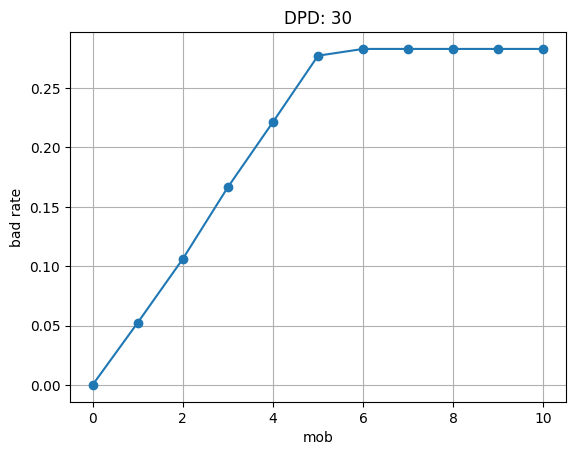

In [26]:
# set dpd label definition
dpd = 30

folder_path = silver_loan_daily_directory
files_list = [folder_path+os.path.basename(f) for f in glob.glob(os.path.join(folder_path, '*'))]
df = spark.read.option("header", "true").parquet(*files_list)

# filter only completed loans
df = df.filter(col("loan_start_date") < datetime.strptime("2024-01-01", "%Y-%m-%d"))

# create dpd flag if more than dpd
df = df.withColumn("dpd_flag", F.when(col("dpd") >= dpd, 1).otherwise(0))

# actual bads
actual_bads_df = df.filter(col("installment_num") == 10)

# visualise bad rate
pdf = df.toPandas()
grouped = pdf.groupby('mob')['dpd_flag'].mean().sort_index()

grouped.plot(kind='line', marker='o')
plt.title('DPD: '+ str(dpd))
plt.xlabel('mob')
plt.ylabel('bad rate')
plt.grid(True)
plt.show()

In [27]:
df.show()

+--------------------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+---+-------------------+-----------------+---+--------+
|             loan_id|Customer_ID|loan_start_date|tenure|installment_num|loan_amt|due_amt|paid_amt|overdue_amt|balance|snapshot_date|mob|installments_missed|first_missed_date|dpd|dpd_flag|
+--------------------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+---+-------------------+-----------------+---+--------+
|CUS_0x1011_2023_1...| CUS_0x1011|     2023-11-01|    10|             10| 10000.0| 1000.0|  1000.0|        0.0|    0.0|   2024-09-01| 10|                  0|             NULL|  0|       0|
|CUS_0x1013_2023_1...| CUS_0x1013|     2023-12-01|    10|              9| 10000.0| 1000.0|  1000.0|        0.0| 1000.0|   2024-09-01|  9|                  0|             NULL|  0|       0|
|CUS_0x1018_2023_1...| CUS_0x1018|     2023-11-01|    1

## Build gold table for labels

In [28]:
# create label store gold datalake
gold_label_store_directory = "datamart/gold/label_store/"

if not os.path.exists(gold_label_store_directory):
    os.makedirs(gold_label_store_directory)

In [29]:
# run gold backfill for label store
for date_str in dates_str_lst:
    utils.data_processing_gold_table.process_labels_gold_table(date_str, silver_loan_daily_directory, gold_label_store_directory, spark, dpd=30, mob=6)

loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_01_01.parquet row count: 530


saved to: datamart/gold/label_store/gold_label_store_2023_01_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_02_01.parquet row count: 1031


saved to: datamart/gold/label_store/gold_label_store_2023_02_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_03_01.parquet row count: 1537


saved to: datamart/gold/label_store/gold_label_store_2023_03_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_04_01.parquet row count: 2047


saved to: datamart/gold/label_store/gold_label_store_2023_04_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_05_01.parquet row count: 2568


...

saved to: datamart/gold/label_store/gold_label_store_2024_09_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2024_10_01.parquet row count: 5502


saved to: datamart/gold/label_store/gold_label_store_2024_10_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2024_11_01.parquet row count: 5501


saved to: datamart/gold/label_store/gold_label_store_2024_11_01.parquet


loaded from: datamart/silver/loan_daily/silver_loan_daily_2024_12_01.parquet row count: 5531


saved to: datamart/gold/label_store/gold_label_store_2024_12_01.parquet


In [30]:
# inspect output
utils.data_processing_gold_table.process_labels_gold_table(date_str, silver_loan_daily_directory, gold_label_store_directory, spark, dpd=30, mob=6).toPandas()

loaded from: datamart/silver/loan_daily/silver_loan_daily_2024_12_01.parquet row count: 5531


saved to: datamart/gold/label_store/gold_label_store_2024_12_01.parquet


,loan_id,Customer_ID,label,label_def,snapshot_date
0,CUS_0x10dd_2024_06_01,CUS_0x10dd,0,30dpd_6mob,2024-12-01
1,CUS_0x1109_2024_06_01,CUS_0x1109,1,30dpd_6mob,2024-12-01
2,CUS_0x1286_2024_06_01,CUS_0x1286,0,30dpd_6mob,2024-12-01
3,CUS_0x12a8_2024_06_01,CUS_0x12a8,0,30dpd_6mob,2024-12-01
4,CUS_0x1309_2024_06_01,CUS_0x1309,0,30dpd_6mob,2024-12-01
...,...,...,...,...,...
493,CUS_0xe51_2024_06_01,CUS_0xe51,0,30dpd_6mob,2024-12-01
494,CUS_0xe72_2024_06_01,CUS_0xe72,0,30dpd_6mob,2024-12-01
495,CUS_0xea5_2024_06_01,CUS_0xea5,0,30dpd_6mob,2024-12-01
496,CUS_0xf70_2024_06_01,CUS_0xf70,0,30dpd_6mob,2024-12-01


## Build gold table for feature store

In [31]:
# create feature store gold datalake
gold_feature_store_directory = "datamart/gold/feature_store/"

if not os.path.exists(gold_feature_store_directory):
    os.makedirs(gold_feature_store_directory)

In [32]:
# run gold backfill for feature store
for date_str in dates_str_lst:
    utils.data_processing_gold_table.process_feature_store_gold_table(
        date_str,
        silver_attributes_directory,
        silver_financials_directory,
        silver_clickstream_directory,
        gold_feature_store_directory,
        spark
    )

2023-01-01 | attributes: 530 | financials: 530 | clickstream: 8974
2023-01-01 | feature store row count: 530


saved to: datamart/gold/feature_store/gold_feature_store_2023_01_01.parquet
2023-02-01 | attributes: 501 | financials: 501 | clickstream: 8974
2023-02-01 | feature store row count: 501


saved to: datamart/gold/feature_store/gold_feature_store_2023_02_01.parquet
2023-03-01 | attributes: 506 | financials: 506 | clickstream: 8974


2023-03-01 | feature store row count: 506


saved to: datamart/gold/feature_store/gold_feature_store_2023_03_01.parquet
2023-04-01 | attributes: 510 | financials: 510 | clickstream: 8974
2023-04-01 | feature store row count: 510


...

saved to: datamart/gold/feature_store/gold_feature_store_2024_09_01.parquet
2024-10-01 | attributes: 456 | financials: 456 | clickstream: 8974
2024-10-01 | feature store row count: 456


saved to: datamart/gold/feature_store/gold_feature_store_2024_10_01.parquet
2024-11-01 | attributes: 488 | financials: 488 | clickstream: 8974


2024-11-01 | feature store row count: 488


saved to: datamart/gold/feature_store/gold_feature_store_2024_11_01.parquet
2024-12-01 | attributes: 515 | financials: 515 | clickstream: 8974
2024-12-01 | feature store row count: 515


saved to: datamart/gold/feature_store/gold_feature_store_2024_12_01.parquet


In [33]:
# inspect output
utils.data_processing_gold_table.process_feature_store_gold_table(
    date_str,
    silver_attributes_directory,
    silver_financials_directory,
    silver_clickstream_directory,
    gold_feature_store_directory,
    spark
).toPandas()

2024-12-01 | attributes: 515 | financials: 515 | clickstream: 8974
2024-12-01 | feature store row count: 515


saved to: datamart/gold/feature_store/gold_feature_store_2024_12_01.parquet


,Customer_ID,Age,Occupation,snapshot_date,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,...,fe_11,fe_12,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20
0,CUS_0x103e,40,Scientist,2024-12-01,98690.796875,8262.233398,4,6,9.0,0,...,0,0,0,0,0,0,0,0,0,0
1,CUS_0x1195,31,Manager,2024-12-01,30429.910156,2808.825928,4,6,16.0,2,...,0,0,0,0,0,0,0,0,0,0
2,CUS_0x1197,28,_______,2024-12-01,92300.007812,7437.667480,2,4,11.0,3,...,0,0,0,0,0,0,0,0,0,0
3,CUS_0x11e2,34,Musician,2024-12-01,44986.550781,3689.879150,6,5,11.0,1,...,0,0,0,0,0,0,0,0,0,0
4,CUS_0x11ec,34,Journalist,2024-12-01,14867.690430,1005.974182,9,9,18.0,6,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
510,CUS_0xe6c,26,Entrepreneur,2024-12-01,125597.523438,9367.500000,1,3,12.0,4,...,0,0,0,0,0,0,0,0,0,0
511,CUS_0xe99,48,Mechanic,2024-12-01,45461.539062,3917.461670,6,3,5.0,2,...,0,0,0,0,0,0,0,0,0,0
512,CUS_0xf55,39,Entrepreneur,2024-12-01,78443.476562,6358.956543,7,5,23.0,4,...,0,0,0,0,0,0,0,0,0,0
513,CUS_0xfd1,32,Architect,2024-12-01,78666.570312,6485.547363,3,4,17.0,4,...,0,0,0,0,0,0,0,0,0,0


## inspect label store

In [34]:
folder_path = gold_label_store_directory
files_list = [folder_path+os.path.basename(f) for f in glob.glob(os.path.join(folder_path, '*'))]
df = spark.read.option("header", "true").parquet(*files_list)
print("row_count:", df.count())
df.show()

row_count: 8974
+--------------------+-----------+-----+----------+-------------+
|             loan_id|Customer_ID|label| label_def|snapshot_date|
+--------------------+-----------+-----+----------+-------------+
|CUS_0x1037_2023_0...| CUS_0x1037|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1069_2023_0...| CUS_0x1069|    0|30dpd_6mob|   2023-07-01|
|CUS_0x114a_2023_0...| CUS_0x114a|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1184_2023_0...| CUS_0x1184|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1297_2023_0...| CUS_0x1297|    1|30dpd_6mob|   2023-07-01|
|CUS_0x12fb_2023_0...| CUS_0x12fb|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1325_2023_0...| CUS_0x1325|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1341_2023_0...| CUS_0x1341|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1375_2023_0...| CUS_0x1375|    1|30dpd_6mob|   2023-07-01|
|CUS_0x13a8_2023_0...| CUS_0x13a8|    0|30dpd_6mob|   2023-07-01|
|CUS_0x13ef_2023_0...| CUS_0x13ef|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1440_2023_0...| CUS_0x1440|    0|30dpd_6mob|   2023-0

In [35]:
df.printSchema()

root
 |-- loan_id: string (nullable = true)
 |-- Customer_ID: string (nullable = true)
 |-- label: integer (nullable = true)
 |-- label_def: string (nullable = true)
 |-- snapshot_date: date (nullable = true)



## inspect feature store

In [36]:
folder_path = gold_feature_store_directory
files_list = [folder_path+os.path.basename(f) for f in glob.glob(os.path.join(folder_path, '*'))]
df = spark.read.option("header", "true").parquet(*files_list)
print("row_count:", df.count())
df.show()

row_count: 11974
+-----------+---+-------------+-------------+-------------+---------------------+-----------------+---------------+-------------+-----------+--------------------+-------------------+----------------------+--------------------+--------------------+----------+----------------+------------------------+---------------------+-------------------+-----------------------+--------------------+---------------+---------------------+----+----+----+----+----+----+----+----+----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+
|Customer_ID|Age|   Occupation|snapshot_date|Annual_Income|Monthly_Inhand_Salary|Num_Bank_Accounts|Num_Credit_Card|Interest_Rate|Num_of_Loan|        Type_of_Loan|Delay_from_due_date|Num_of_Delayed_Payment|Changed_Credit_Limit|Num_Credit_Inquiries|Credit_Mix|Outstanding_Debt|Credit_Utilization_Ratio|Payment_of_Min_Amount|Total_EMI_per_month|Amount_invested_monthly|   Payment_Behaviour|Monthly_Balance|Credit_History_Months|fe_1|fe_2|fe_3|fe_4|f

In [37]:
df.printSchema()

root
 |-- Customer_ID: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Occupation: string (nullable = true)
 |-- snapshot_date: date (nullable = true)
 |-- Annual_Income: float (nullable = true)
 |-- Monthly_Inhand_Salary: float (nullable = true)
 |-- Num_Bank_Accounts: integer (nullable = true)
 |-- Num_Credit_Card: integer (nullable = true)
 |-- Interest_Rate: float (nullable = true)
 |-- Num_of_Loan: integer (nullable = true)
 |-- Type_of_Loan: string (nullable = true)
 |-- Delay_from_due_date: integer (nullable = true)
 |-- Num_of_Delayed_Payment: integer (nullable = true)
 |-- Changed_Credit_Limit: float (nullable = true)
 |-- Num_Credit_Inquiries: float (nullable = true)
 |-- Credit_Mix: string (nullable = true)
 |-- Outstanding_Debt: float (nullable = true)
 |-- Credit_Utilization_Ratio: float (nullable = true)
 |-- Payment_of_Min_Amount: string (nullable = true)
 |-- Total_EMI_per_month: float (nullable = true)
 |-- Amount_invested_monthly: float (nullable = t